In [11]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [10]:
!{sys.executable} -m pip install scikit-learn xgboost pandas seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 5.6 MB/s eta 0:00:00 MB/s eta 0:00:01


In [12]:
from mne.datasets import eegbci

subject = 1
runs = [6, 10]

raw_fnames = eegbci.load_data(subject, runs)

Using default location ~/mne_data for EEGBCI...
Creating /Users/jessicaescalante/mne_data


Do you want to set the path:
    /Users/jessicaescalante/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n?  y


Attempting to create new mne-python configuration file:
/Users/jessicaescalante/.mne/mne-python.json
Could not read the /Users/jessicaescalante/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m35s (5.0 MB)


In [13]:
raw = mne.io.concatenate_raws(
    [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
)

Extracting EDF parameters from /Users/jessicaescalante/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /Users/jessicaescalante/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [14]:
eegbci.standardize(raw)

montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage)

print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


In [15]:
raw.filter(1., 40., method='iir')

Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 1 - 40 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 40.00 Hz: -6.02, -6.02 dB



<RawEDF | S001R06.edf, 64 x 40000 (250.0 s), ~19.6 MiB, data loaded>

In [16]:
events, event_id = mne.events_from_annotations(raw)
print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [17]:
event_id_selected = dict(T1=event_id['T1'], T2=event_id['T2'])

epochs = mne.Epochs(
    raw,
    events,
    event_id_selected,
    tmin=-0.5,
    tmax=4.,
    baseline=(None, 0),
    preload=True
)

print(epochs)

Not setting metadata
30 matching events found
Setting baseline interval to [-0.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 721 original time points ...
0 bad epochs dropped
<Epochs | 30 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~10.6 MiB, data loaded,
 'T1': 14
 'T2': 16>


In [19]:
print(epochs.event_id)
print(f"Total epochs: {len(epochs)}")

{'T1': 2, 'T2': 3}
Total epochs: 30


In [20]:
from scipy import signal as scipy_signal

channels_of_interest = ['C3', 'Cz', 'C4']

frequency_bands = [
    ('delta', 0.5, 4),
    ('theta', 4,   8),
    ('alpha', 8,  13),
    ('beta',  13, 30),
    ('gamma', 30, 40),
]

data = epochs.get_data(picks=channels_of_interest)
sfreq = epochs.info['sfreq']

print(f"Data shape: {data.shape}")

Data shape: (30, 3, 721)


In [22]:
features_list = []

for epoch_idx in range(data.shape[0]):
    epoch_features = {}
    
    for ch_idx, ch_name in enumerate(channels_of_interest):
        signal_segment = data[epoch_idx, ch_idx, :]
        
        freqs, psd = scipy_signal.welch(signal_segment, sfreq, nperseg=int(sfreq))
        
        for band_name, fmin, fmax in frequency_bands:
            band_mask = (freqs >= fmin) & (freqs <= fmax)
            band_power = np.trapezoid(psd[band_mask], freqs[band_mask])
            epoch_features[f"{ch_name}_{band_name}"] = band_power
    
    features_list.append(epoch_features)

X = pd.DataFrame(features_list)
print(X.shape)
print(X.head())

(30, 15)
       C3_delta      C3_theta      C3_alpha       C3_beta      C3_gamma  \
0  3.976643e-10  2.173099e-10  1.948826e-10  1.532118e-10  1.898494e-11   
1  1.243184e-09  2.238530e-10  1.261492e-10  1.234127e-10  1.723786e-11   
2  7.195900e-10  3.659626e-10  2.426966e-10  1.713334e-10  2.104478e-11   
3  4.985137e-10  1.865311e-10  2.615981e-10  2.111000e-10  2.072325e-11   
4  1.861496e-09  4.477931e-10  2.589923e-10  2.499055e-10  2.218152e-11   

       Cz_delta      Cz_theta      Cz_alpha       Cz_beta      Cz_gamma  \
0  5.034506e-10  2.479653e-10  1.422234e-10  1.599177e-10  3.413761e-11   
1  1.356145e-09  2.774638e-10  1.427792e-10  2.141302e-10  3.425081e-11   
2  8.931630e-10  4.270309e-10  2.484609e-10  1.591061e-10  1.845370e-11   
3  6.353117e-10  2.263835e-10  2.193708e-10  2.174025e-10  2.591711e-11   
4  1.984279e-09  5.609255e-10  3.272929e-10  2.409128e-10  2.701084e-11   

       C4_delta      C4_theta      C4_alpha       C4_beta      C4_gamma  
0  3.562701e-10

In [23]:
labels_raw = epochs.events[:, 2]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform([str(l) for l in labels_raw])

print(f"Classes found: {le.classes_}")
print(f"First 10 labels: {y[:10]}")
print(f"Class distribution: T1={sum(y==0)}, T2={sum(y==1)}")

Classes found: ['2' '3']
First 10 labels: [1 0 0 1 0 1 1 0 0 1]
Class distribution: T1=14, T2=16


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (24, 15)
Test set: (6, 15)


In [26]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [27]:
model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['T1 (left)', 'T2 (right)']))

Test accuracy: 50.00%

Classification report:
              precision    recall  f1-score   support

   T1 (left)       0.50      0.67      0.57         3
  T2 (right)       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model, X_train_scaled, y_train,
    cv=5,
    scoring='accuracy'
)

print(f"CV scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.2%}")
print(f"Std deviation: {cv_scores.std():.2%}")

CV scores: [0.8 0.8 0.4 0.2 0.5]
Mean accuracy: 54.00%
Std deviation: 23.32%


Cz_gamma    0.273653
C3_beta     0.178690
Cz_delta    0.108836
C3_delta    0.087976
C3_gamma    0.080718
C3_alpha    0.065110
Cz_theta    0.058909
C4_delta    0.051424
C4_theta    0.034901
Cz_alpha    0.032340
dtype: float32


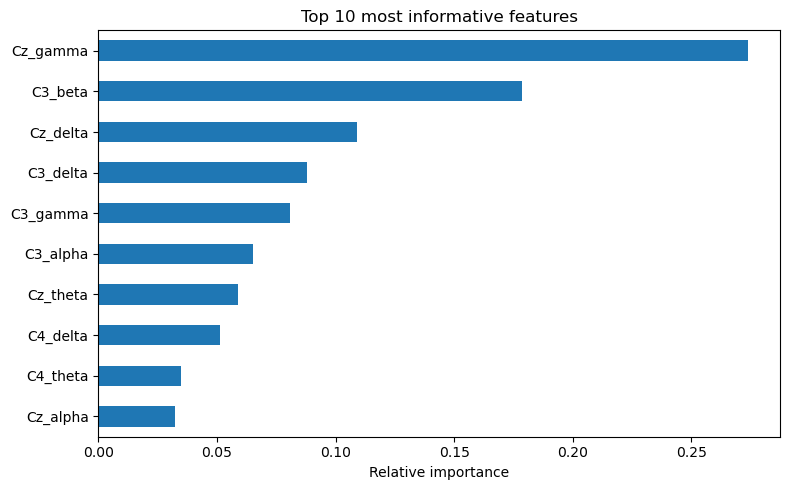

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

feature_importance.head(10).plot(kind='barh', figsize=(8,5))
plt.xlabel("Relative importance")
plt.title("Top 10 most informative features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

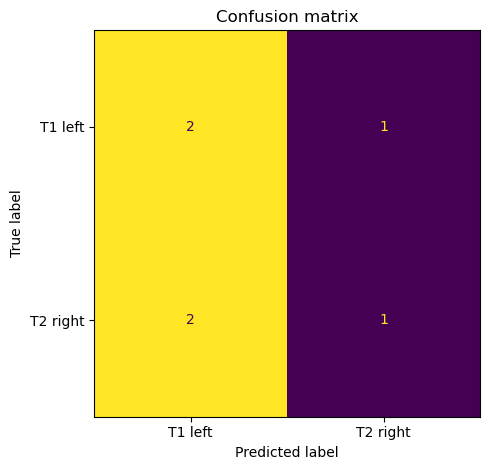

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=['T1 left', 'T2 right'])
disp.plot(colorbar=False)
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

In [37]:
fig1, ax1 = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['T1 left', 'T2 right'])
disp.plot(colorbar=False, ax=ax1)
ax1.set_title("Confusion matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.close()

fig2, ax2 = plt.subplots(figsize=(8, 5))
feature_importance.head(10).plot(kind='barh', ax=ax2)
ax2.set_xlabel("Relative importance")
ax2.set_title("Top 10 most informative features")
ax2.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.close()

print("Figures saved.")

Figures saved.
